# Softmax, Cross-Entropy, and Your First Classifier (M0)

The refresher's finale connects the loop to the loss every LLM trains with. An LLM is a
classifier over its vocabulary — at each position it scores 32K–128K candidate tokens, and
those scores are trained with exactly what this chapter builds:

1. **Softmax** — scores to probabilities, with temperature and a stability trick
2. **Cross-entropy** — the "surprise" loss, and why MSE is the wrong tool
3. **The `p − y` gradient** — derived by the chapter-01 engine, verified against PyTorch
4. **Milestone M0** — train an MLP classifier from scratch on the 3-class spiral

### Concepts covered

| # | Concept | What to watch for |
|---|---------|-------------------|
| 1 | Softmax | exp-and-normalize; temperature reshapes, subtract-max stabilizes |
| 2 | Cross-entropy | −log p(correct): cheap when right, catastrophic when confidently wrong |
| 3 | CE vs MSE | MSE's gradient *vanishes* exactly where learning is most needed |
| 4 | `p − y` | The gradient at the logits is just probabilities minus targets |
| 5 | Logits → loss | The same pipeline as the LLM output head, at vocab_size = 3 |

Reference: [docs/CONCEPTS.md § loss function](../../docs/CONCEPTS.md) · [docs/PAPERS.md](../../docs/PAPERS.md)

::: {.callout-tip title="📺 Video companion"}
Chapter 4 of 3Blue1Brown's series,
[backpropagation calculus](https://www.youtube.com/watch?v=tIeHLnjs5U8), works the same
loss derivative by hand — more in [Videos](../../docs/VIDEOS.md).
:::

::: {.callout-note title="🎯 Goal — why this chapter, for the capstone"}
Your capstone LLM's output head is this chapter with more columns: hidden states meet a
`(dim, vocab_size)` matrix, softmax turns the scores into a next-token distribution, and
cross-entropy on the correct token is the entire training signal
([the loss deep-dive](../../docs/CONCEPTS.md) traces the tensor shapes). Even generation
is here: `generate_tiny` in the
[Transformer Overview](../01_transformer_internals/00_transformer_overview.ipynb) is
softmax + temperature + sampling, verbatim.

This chapter closes the refresher by doing the whole pipeline at `vocab_size = 3` — small
enough to check every number by hand, identical in shape to the real thing.

🏗️ **Chapter milestone:** M0 — train an MLP classifier from scratch (end of this
chapter): your engine's gradients matched against PyTorch to 1e-6, and a spiral classifier
at ≥95% accuracy.
:::

::: {.callout-tip title="⏱️ Sessions S0.4–S0.5" appearance="simple"}
Two sessions: S0.4 reads the chapter; S0.5 is 🏗️ milestone M0 — the classifier trained with your own engine.
Cards, prerequisites, and done-when tests: the [Session Guide](../../docs/SESSIONS.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/00_dnn_refresher/03_softmax_crossentropy.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from ai_playground.fundamentals import Value, make_spiral

## 1. Softmax: scores to probabilities

A model's raw outputs (logits) are unbounded scores. Softmax —
`exp` each score, divide by the sum — turns them into a probability distribution that
keeps the *ranking* while making the *confidence* explicit. **Temperature** divides the
logits first: T < 1 sharpens toward argmax, T > 1 flattens toward uniform. This is the
same T you set when sampling from an LLM.

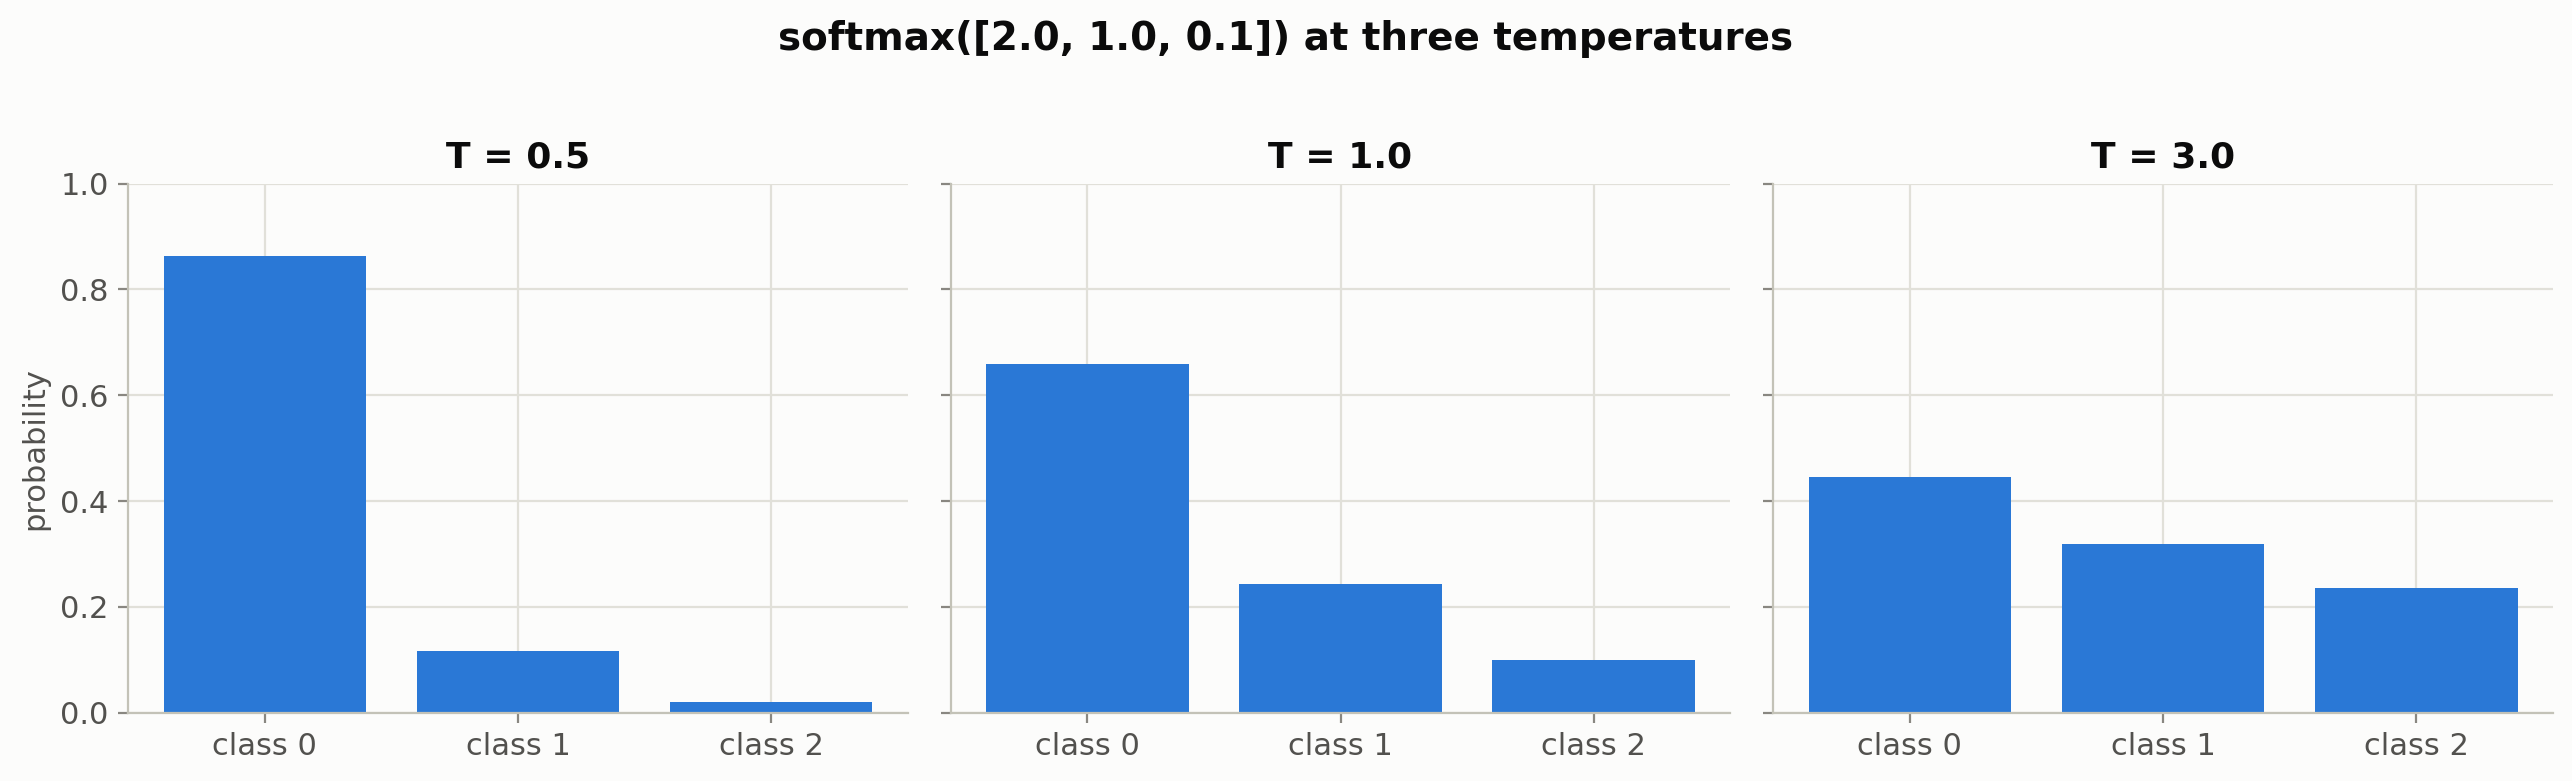

In [3]:
def softmax(z, temperature=1.0):
    z = np.asarray(z, dtype=np.float64) / temperature
    e = np.exp(z - z.max())        # subtract-max: see below
    return e / e.sum()

logits = np.array([2.0, 1.0, 0.1])
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, T in zip(axes, [0.5, 1.0, 3.0]):
    ax.bar(['class 0', 'class 1', 'class 2'], softmax(logits, T))
    ax.set_title(f'T = {T}')
    ax.set_ylim(0, 1)
axes[0].set_ylabel('probability')
fig.suptitle('softmax([2.0, 1.0, 0.1]) at three temperatures', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Why subtract the max: exp overflows float64 near z = 710, and LLM logits can spike.
z = np.array([1000.0, 999.0, 0.0])
with np.errstate(over='ignore', invalid='ignore'):
    naive = np.exp(z) / np.exp(z).sum()
print('naive softmax([1000, 999, 0])  =', naive)                # nan — exp(1000) = inf
print('stable (subtract max) version =', softmax(z))
# Softmax is shift-invariant — softmax(z) == softmax(z - c) — so subtracting max(z)
# changes nothing mathematically and everything numerically.

naive softmax([1000, 999, 0])  = [nan nan  0.]
stable (subtract max) version = [0.73105858 0.26894142 0.        ]


## 2. Cross-entropy: the surprise loss

Cross-entropy scores a prediction by the log of the probability it assigned to the truth:
`L = −log p(correct)`. Read it as *surprise*: p = 0.99 costs 0.01 nats, p = 0.01 costs
4.6. And its gradient is exactly what a learning signal should be — compare what happens
to MSE-on-probabilities when the model is *confidently wrong*:

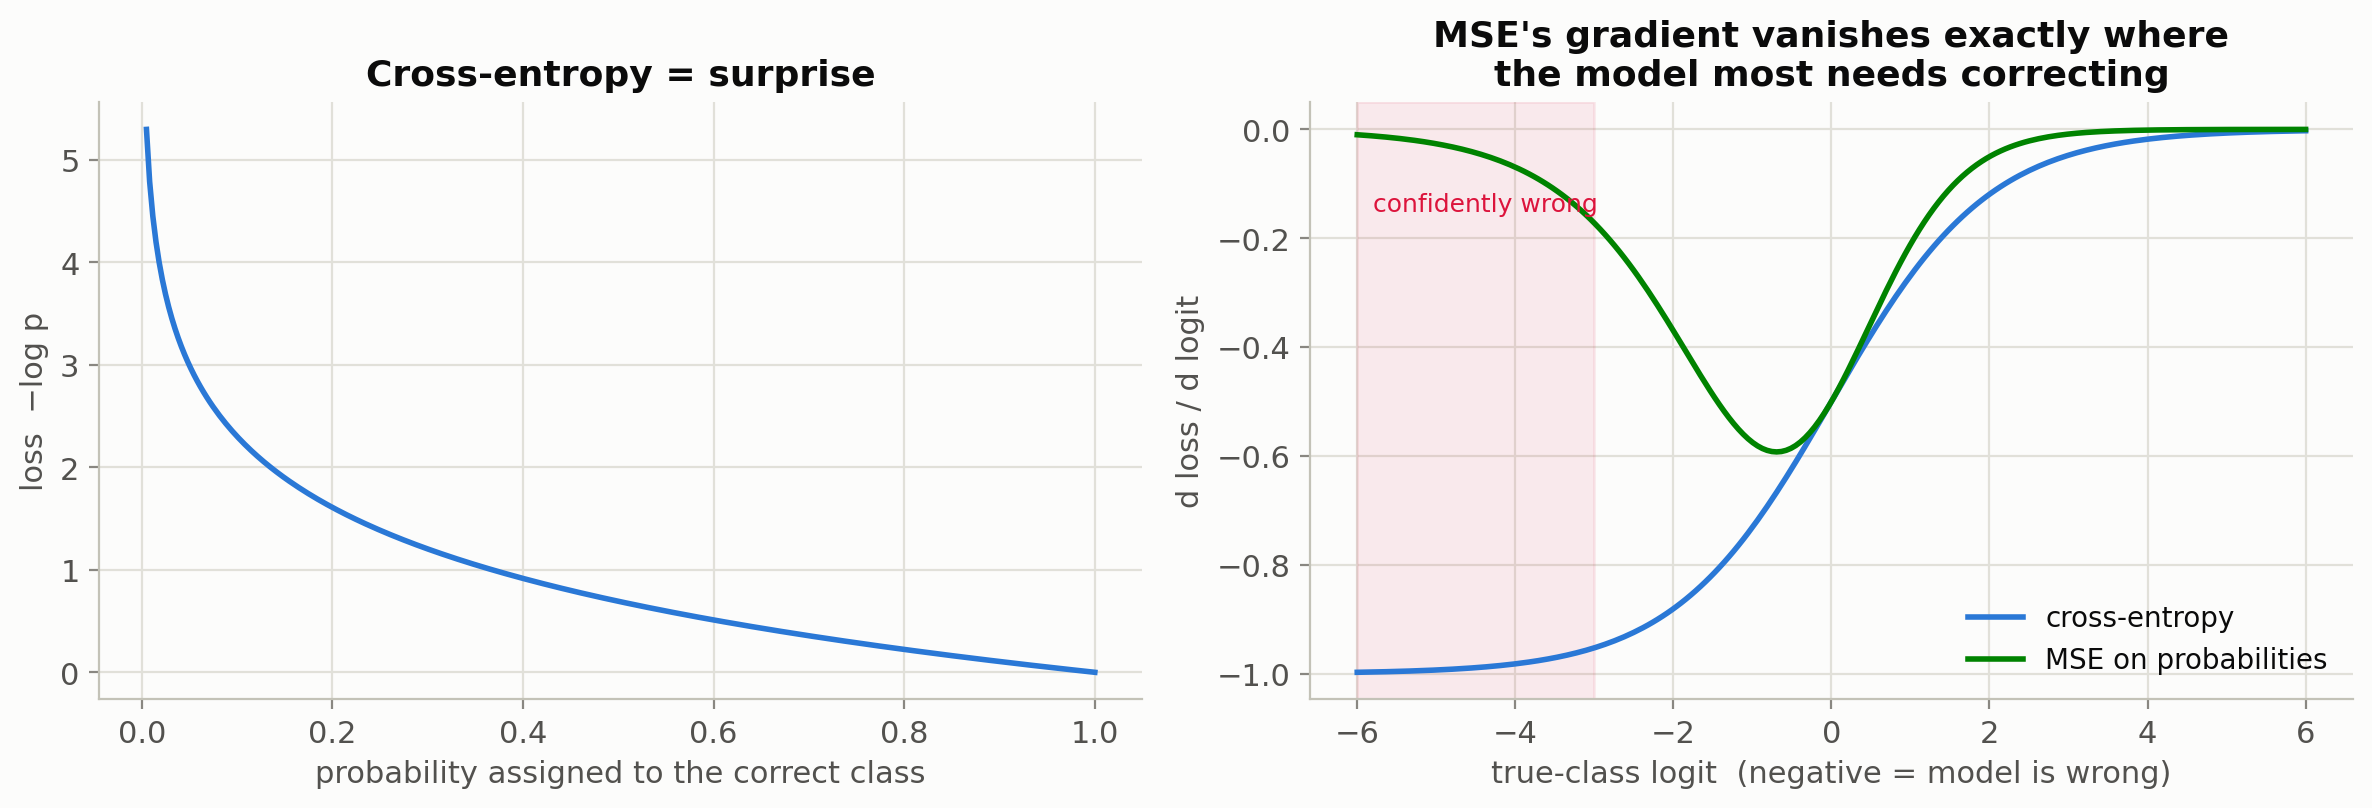

In [5]:
#| code-fold: true
#| code-summary: "Plot: −log p, and CE vs MSE gradients when the model is wrong"
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

p = np.linspace(0.005, 1.0, 300)
axes[0].plot(p, -np.log(p))
axes[0].set_xlabel('probability assigned to the correct class')
axes[0].set_ylabel('loss  −log p')
axes[0].set_title('Cross-entropy = surprise')

# Two classes, true class 0: sweep the true-class logit z (other fixed at 0)
# and plot dL/dz for CE vs MSE-on-softmax, computed by torch autograd.
zs = np.linspace(-6, 6, 200)
grads = {'cross-entropy': [], 'MSE on probabilities': []}
for z0 in zs:
    for name in grads:
        zt = torch.tensor([z0, 0.0], requires_grad=True)
        probs = torch.softmax(zt, dim=0)
        loss = (-torch.log(probs[0]) if name == 'cross-entropy'
                else ((probs - torch.tensor([1.0, 0.0])) ** 2).sum())
        loss.backward()
        grads[name].append(zt.grad[0].item())
for name, g in grads.items():
    axes[1].plot(zs, g, label=name)
axes[1].axvspan(-6, -3, color='crimson', alpha=0.08)
axes[1].text(-5.8, -0.15, 'confidently wrong', fontsize=9, color='crimson')
axes[1].set_xlabel('true-class logit  (negative = model is wrong)')
axes[1].set_ylabel('d loss / d logit')
axes[1].legend()
axes[1].set_title("MSE's gradient vanishes exactly where\nthe model most needs correcting")
plt.tight_layout()
plt.show()

That red zone is the argument: with MSE on probabilities, a *very* wrong model gets a
near-zero gradient (the softmax has saturated) and learns nothing. Cross-entropy's
gradient stays large until the model is actually right. The deeper reason it's the LLM
loss — maximum likelihood over the vocabulary — is in
[docs/CONCEPTS.md](../../docs/CONCEPTS.md).

## 3. The famous gradient: `p − y`

Push one sample through softmax + cross-entropy *with the chapter-01 engine* — its `exp`
and `log` are all we need — and read the logit gradients off the graph. The claimed
closed form: **probabilities minus one-hot target**.

In [6]:
logits = [Value(2.0), Value(1.0), Value(0.1)]
target = 0                                       # true class

exps = [z.exp() for z in logits]
total = exps[0] + exps[1] + exps[2]
probs = [e / total for e in exps]
loss = -(probs[target].log())                    # cross-entropy, built from scratch
loss.backward()

p_np = softmax([2.0, 1.0, 0.1])
y_onehot = np.eye(3)[target]
print(f'{"class":>5}  {"engine dL/dz":>13}  {"p − y":>13}')
for k in range(3):
    print(f'{k:>5}  {logits[k].grad:>13.8f}  {p_np[k] - y_onehot[k]:>13.8f}')

# And against torch.nn.functional.cross_entropy (which fuses all of the above):
zt = torch.tensor([[2.0, 1.0, 0.1]], requires_grad=True)
F.cross_entropy(zt, torch.tensor([target])).backward()
assert np.allclose([z.grad for z in logits], zt.grad[0].numpy(), atol=1e-6)
print('\nmatches F.cross_entropy grads to 1e-6 ✓')

class   engine dL/dz          p − y
    0    -0.34099886    -0.34099886
    1     0.24243297     0.24243297
    2     0.09856589     0.09856589

matches F.cross_entropy grads to 1e-6 ✓


`p − y` is worth memorizing: the entire softmax + log + normalize pipeline collapses to
"how much probability did you put where it didn't belong". It's also why frameworks fuse
softmax into the loss (`F.cross_entropy` takes *logits*) — the fused backward is this
one subtraction, with none of the intermediate graph.

## 4. M0's task: the 3-class spiral

`make_spiral` interleaves three arms — the CS231n classic. First, proof that *our* engine
can learn it (briefly, on a subset — scalar autograd pays per node), then the full run in
PyTorch:

In [7]:
from ai_playground.fundamentals import MLP, plot_decision_boundary

X, y = make_spiral(n_per_class=100, n_classes=3, noise=0.2, seed=0)

# --- scalar engine, small slice: prove the machinery learns ---
idx = np.random.default_rng(0).permutation(len(X))[:60]
Xs, ys = X[idx], y[idx]
m = MLP(2, [8, 3], seed=2)

def ce_loss(model, Xb, yb):
    total = None
    for xi, yi in zip(Xb, yb):
        zs = model([*xi])
        exps = [z.exp() for z in zs]
        denom = exps[0] + exps[1] + exps[2]
        nll = -((exps[int(yi)] / denom).log())
        total = nll if total is None else total + nll
    return total / len(Xb)

start = ce_loss(m, Xs, ys).data
for step in range(150):
    loss = ce_loss(m, Xs, ys)
    m.zero_grad(); loss.backward()
    for p in m.parameters():
        p.data -= 2.0 * p.grad

acc = np.mean([int(np.argmax([z.data for z in m([*xi])])) == yi for xi, yi in zip(Xs, ys)])
print(f'scalar engine on 60 points: CE {start:.3f} -> {ce_loss(m, Xs, ys).data:.3f}, '
      f'accuracy {acc:.0%} (chance: 33%)')
print('The engine learns — now let torch handle the full 300 points at speed.')

scalar engine on 60 points: CE 1.098 -> 0.449, accuracy 77% (chance: 33%)
The engine learns — now let torch handle the full 300 points at speed.


In [8]:
# --- PyTorch, full 300 points ---
tmodel = torch.nn.Sequential(torch.nn.Linear(2, 32), torch.nn.Tanh(),
                             torch.nn.Linear(32, 32), torch.nn.Tanh(),
                             torch.nn.Linear(32, 3))
opt = torch.optim.Adam(tmodel.parameters(), lr=0.01)
tX, ty = torch.tensor(X, dtype=torch.float32), torch.tensor(y)

curve, acc_curve = [], []
for step in range(400):
    logits_t = tmodel(tX)
    loss = F.cross_entropy(logits_t, ty)      # fused softmax + CE, gradient p − y
    curve.append(loss.item())
    acc_curve.append((logits_t.argmax(1) == ty).float().mean().item())
    opt.zero_grad(); loss.backward(); opt.step()

train_acc = acc_curve[-1]
print(f'final CE {curve[-1]:.4f}, train accuracy {train_acc:.1%} on 300 points')

final CE 0.0022, train accuracy 100.0% on 300 points


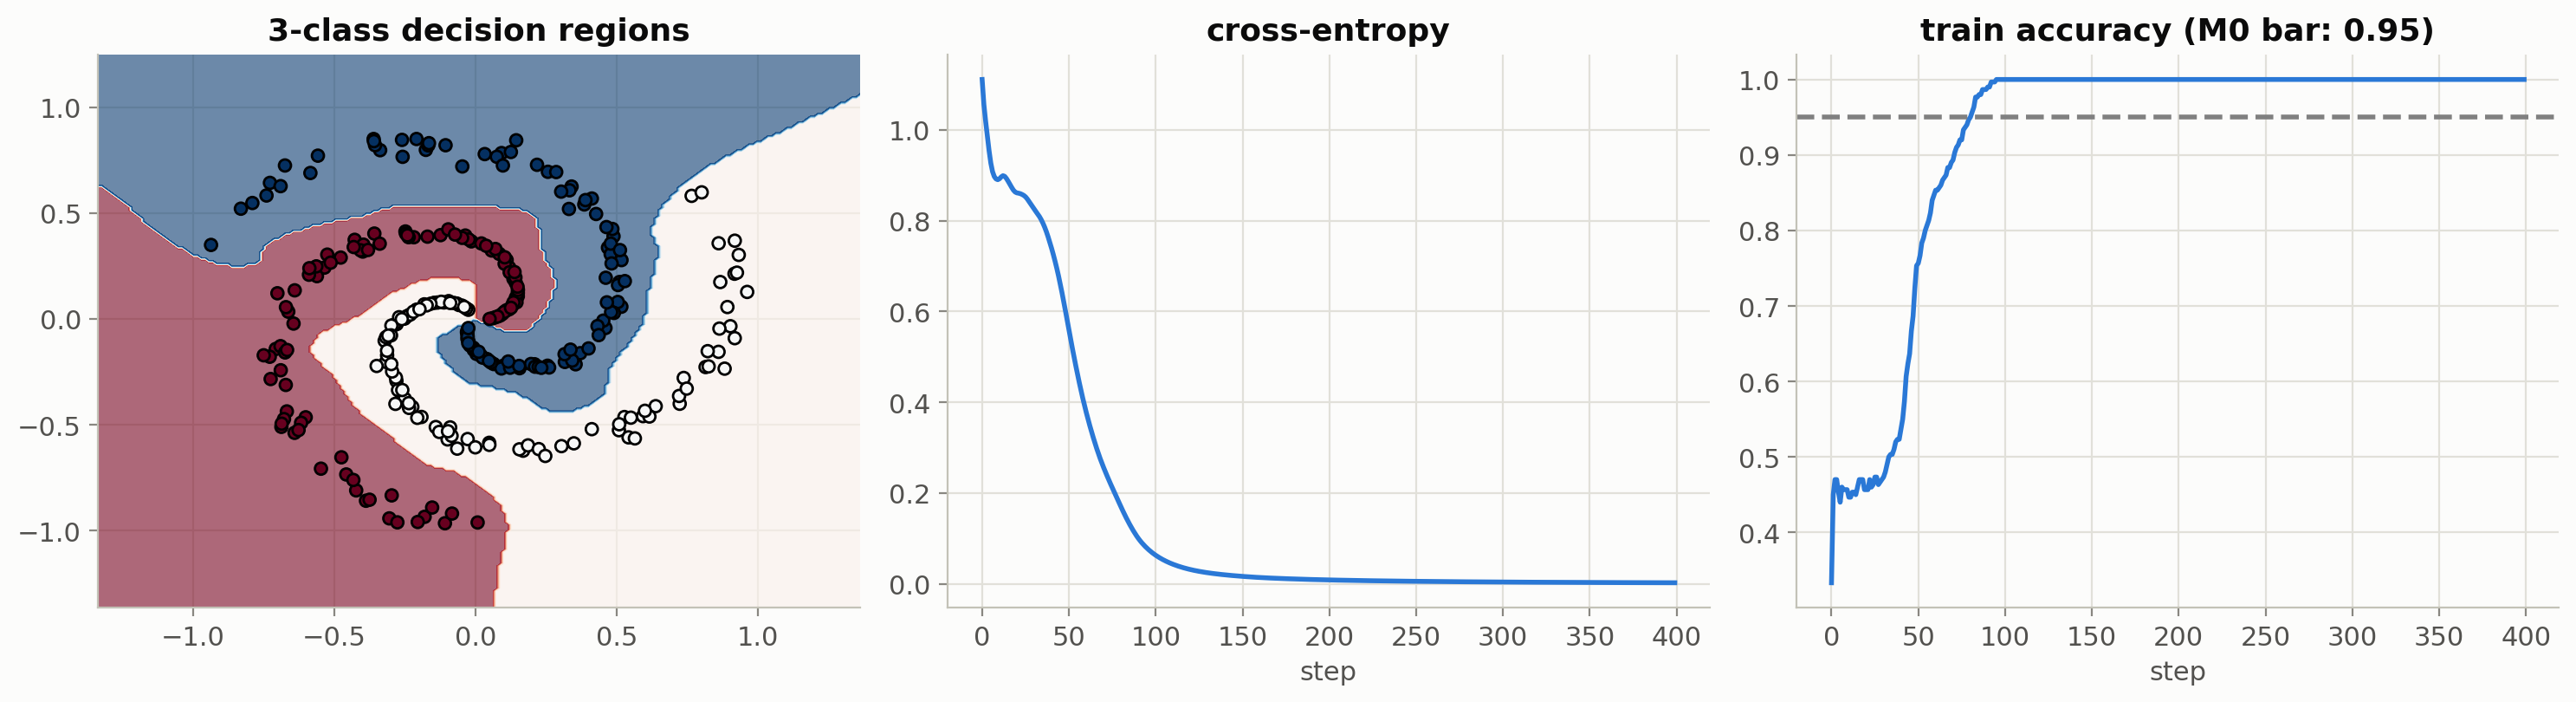

In [9]:
#| code-fold: true
#| code-summary: "Plot: decision regions, loss and accuracy curves"
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
with torch.no_grad():
    plot_decision_boundary(
        lambda g: tmodel(torch.tensor(g, dtype=torch.float32)).argmax(1).numpy(),
        X, y, ax=axes[0])
axes[0].set_title('3-class decision regions')
axes[1].plot(curve); axes[1].set_title('cross-entropy'); axes[1].set_xlabel('step')
axes[2].plot(acc_curve); axes[2].axhline(0.95, ls='--', c='gray')
axes[2].set_title('train accuracy (M0 bar: 0.95)'); axes[2].set_xlabel('step')
plt.tight_layout()
plt.show()

## 5. From 3 classes to 32,000

Swap the spiral's 2 features for `dim`-dimensional hidden states and its 3 classes for a
vocabulary, and nothing else changes: the LLM output head is `h @ W_out` into
`F.cross_entropy`, gradient `p − y` over `vocab_size` entries per position. That single
matmul is visualized in 3D in the
[Transformer Overview](../01_transformer_internals/00_transformer_overview.ipynb) (§4b),
and the full tensor-shape walk lives in
[docs/CONCEPTS.md § loss function](../../docs/CONCEPTS.md). What changes at scale is
only *engineering*: at vocab 128K the logits row is the biggest tensor in the step, which
is why fused softmax-CE kernels exist.

## 🏗️ Project milestone M0 — train an MLP classifier from scratch

::: {.callout-note appearance="simple"}
Close the refresher by proving both halves of it on your own machine: your engine's
gradients are *correct*, and the loop they power actually *learns*.

```python
from pathlib import Path
WS = Path('../../checkpoints/myllm')
WS.mkdir(parents=True, exist_ok=True)
```

1. **Gradient parity** — build one spiral batch (16 points), compute softmax + CE with
   `ai_playground.fundamentals` (`Value`, `MLP(2, [8, 3])`) and with an identical-weight
   torch model (the weight-copy recipe is in
   `tests/test_fundamentals.py::TestMLP::test_grad_parity_with_torch`). Record the max
   absolute gradient difference.
2. **Spiral accuracy** — train any MLP you like (torch allowed — the loop is chapter 02's)
   on the full 300-point spiral; record final train accuracy.

```python
import json
metrics = json.load(open(WS / 'metrics.json')) if (WS / 'metrics.json').exists() else {}
metrics['m0_grad_max_abs_diff'] = float(max_abs_diff)
metrics['m0_spiral_train_acc'] = float(train_acc)
json.dump(metrics, open(WS / 'metrics.json', 'w'), indent=2)
```

**Accept when**: `m0_grad_max_abs_diff < 1e-6`, `m0_spiral_train_acc >= 0.95`, and both
keys are in `metrics.json`. Part of [The Project: Serve Your Own LLM](../../docs/PROJECT.md).

**Session [S0.5](../../docs/SESSIONS.md)** — verify: `uv run pytest tests/milestones/test_m00_classifier.py`.
:::

## Key Takeaways

1. **Softmax = exp-and-normalize**, temperature reshapes confidence, and subtract-max
   costs nothing (shift invariance) while preventing overflow — the reason every real
   implementation does it.
2. **Cross-entropy is surprise**, and its gradient survives where MSE's dies: a
   confidently-wrong model gets a full-strength correction instead of a saturated zero.
3. **`p − y`** — the whole softmax+CE backward collapses to probabilities minus targets,
   derived here by the scalar engine and matched to `F.cross_entropy` at 1e-6.
4. **An LLM is this classifier with a huge class count**: same head, same loss, same
   gradient, per token position.
5. **M0 done** means the refresher's promise is kept: an engine you built, verified
   against PyTorch, driving a loop you understand, hitting ≥95% on a task a linear model
   cannot touch. The main path resumes at the
   [Transformer Overview](../01_transformer_internals/00_transformer_overview.ipynb) —
   where milestone **M1** designs the model this classifier grows into.

---

## 🔨 From-scratch project: p0 — Autograd from a blank file

You've now run every piece of the refresher — and the M0 milestone had you *re-apply* the repo's engine. The phase's from-scratch project asks for more: rebuild the whole stack (scalar autograd, an MLP, a training loop that separates the moons) with nothing open but a blank file. Scaffolding covers the boilerplate; the acceptance tests check your gradients against central finite differences, not against any library.

Brief and rules: [projects/p0_grad_engine/README.md](../../projects/p0_grad_engine/README.md)

```bash
uv run pytest projects/p0_grad_engine/ -v
```